# Subtask 3 — Decoder-Only Transformers for Poetry Generation

## 1. Setup & Imports

In [1]:
import os
import re
import math
import time
import random
import collections
from copy import deepcopy

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam, AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

from datasets import load_dataset

# reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cuda


## 2. Load & Explore the Dataset

In [2]:
ds = load_dataset("merve/poetry")
print(ds)
print("\nSample entry:")
print(ds['train'][0])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/2.81k [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


poetry.csv:   0%|          | 0.00/606k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/573 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['author', 'content', 'poem name', 'age', 'type'],
        num_rows: 573
    })
})

Sample entry:
{'author': 'WILLIAM SHAKESPEARE', 'content': 'Let the bird of loudest lay\r\nOn the sole Arabian tree\r\nHerald sad and trumpet be,\r\nTo whose sound chaste wings obey.\r\n\r\nBut thou shrieking harbinger,\r\nFoul precurrer of the fiend,\r\nAugur of the fever\'s end,\r\nTo this troop come thou not near.\r\n\r\nFrom this session interdict\r\nEvery fowl of tyrant wing,\r\nSave the eagle, feather\'d king;\r\nKeep the obsequy so strict.\r\n\r\nLet the priest in surplice white,\r\nThat defunctive music can,\r\nBe the death-divining swan,\r\nLest the requiem lack his right.\r\n\r\nAnd thou treble-dated crow,\r\nThat thy sable gender mak\'st\r\nWith the breath thou giv\'st and tak\'st,\r\n\'Mongst our mourners shalt thou go.\r\n\r\nHere the anthem doth commence:\r\nLove and constancy is dead;\r\nPhoenix and the Turtle fled\r\nIn a mutual flame 

Total poems: 573
Avg poem length (chars): 989.9


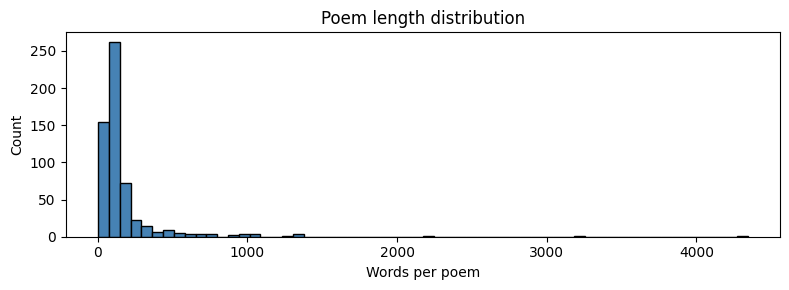

Median: 113 words | Max: 4342 | Min: 3


In [3]:
# pull the raw poem text
all_poems = [entry['content'] for entry in ds['train']]
print(f"Total poems: {len(all_poems)}")
print(f"Avg poem length (chars): {np.mean([len(p) for p in all_poems]):.1f}")

# quick look at the distribution of poem lengths
lengths = [len(p.split()) for p in all_poems]
plt.figure(figsize=(8, 3))
plt.hist(lengths, bins=60, edgecolor='black', color='steelblue')
plt.xlabel('Words per poem')
plt.ylabel('Count')
plt.title('Poem length distribution')
plt.tight_layout()
plt.show()
print(f"Median: {np.median(lengths):.0f} words | Max: {max(lengths)} | Min: {min(lengths)}")

In [4]:
print("Columns:", ds['train'].column_names)

# look at poetry types
if 'type' in ds['train'].column_names:
    types = collections.Counter([e['type'] for e in ds['train']])
    print("\nTop poetry types:")
    for t, c in types.most_common(10):
        print(f"  {t}: {c}")

Columns: ['author', 'content', 'poem name', 'age', 'type']

Top poetry types:
  Love: 326
  Nature: 188
  Mythology & Folklore: 59


In [5]:
# concatenate all poems into one big corpus string
corpus = "\n\n".join(all_poems)
print(f"Total corpus characters: {len(corpus):,}")
print("\nFirst 500 chars:")
print(corpus[:500])

Total corpus characters: 568,345

First 500 chars:
Let the bird of loudest lay
On the sole Arabian tree
Herald sad and trumpet be,
To whose sound chaste wings obey.

But thou shrieking harbinger,
Foul precurrer of the fiend,
Augur of the fever's end,
To this troop come thou not near.

From this session interdict
Every fowl of tyrant wing,
Save the eagle, feather'd king;
Keep the obsequy so strict.

Let the priest in surplice white,
That defunctive music can,
Be the death-divining swan,
Lest the requiem lack his right.

And th


## 3. Tokenization

We'll build three tokenizers and compare them in the ablation section:
1. **Character-level** - smallest vocabulary, lots of steps per poem
2. **Word-level** - larger vocab, shorter sequences  
3. **BPE (subword)** - middle ground, handles unseen words better

For most experiments we default to **word-level** since it gives reasonable sequence lengths and vocab sizes without external libraries.

In [6]:
# ─────────────────────────────────────────────
#  3a. Character-level tokenizer
# ─────────────────────────────────────────────

class CharTokenizer:
    def __init__(self, text):
        chars = sorted(set(text))
        self.PAD = 0
        self.UNK = 1
        self.BOS = 2
        self.EOS = 3
        self.vocab_size = len(chars) + 4        # +4 for PAD, UNK, BOS, EOS
        self.ch2id = {c: i+4 for i, c in enumerate(chars)}
        self.id2ch = {i+4: c for i, c in enumerate(chars)}
        self.id2ch[0] = '<PAD>'
        self.id2ch[1] = '<UNK>'
        self.id2ch[2] = '<BOS>'
        self.id2ch[3] = '<EOS>'

    def encode(self, text, add_special=False):
        ids = [self.ch2id.get(c, self.UNK) for c in text]
        if add_special:
            ids = [self.BOS] + ids + [self.EOS]
        return ids

    def decode(self, ids, skip_special=True):
        skip = {self.PAD, self.BOS, self.EOS} if skip_special else {self.PAD}
        return ''.join(self.id2ch.get(i, '') for i in ids if i not in skip)


char_tok = CharTokenizer(corpus)
print(f"Char vocab size: {char_tok.vocab_size}")
sample_enc = char_tok.encode("Shall I compare thee")
print(f"Encoded: {sample_enc}")
print(f"Decoded: {char_tok.decode(sample_enc)}")

Char vocab size: 87
Encoded: [48, 66, 59, 70, 70, 6, 38, 6, 61, 73, 71, 74, 59, 76, 63, 6, 78, 66, 63, 63]
Decoded: Shall I compare thee


In [7]:
# ─────────────────────────────────────────────
#  3b. Word-level tokenizer  (main default)
# ─────────────────────────────────────────────

def simple_tokenize(text):
    # keep punctuation as separate tokens
    tokens = re.findall(r"\w+|[^\w\s]", text.lower())
    return tokens

class WordTokenizer:
    def __init__(self, texts, max_vocab=10000):
        counter = collections.Counter()
        for t in texts:
            counter.update(simple_tokenize(t))

        self.PAD = 0
        self.UNK = 1
        self.BOS = 2
        self.EOS = 3
        special = ['<PAD>', '<UNK>', '<BOS>', '<EOS>']
        vocab_words = [w for w, _ in counter.most_common(max_vocab - len(special))]
        vocab = special + vocab_words

        self.vocab_size = len(vocab)
        self.w2id = {w: i for i, w in enumerate(vocab)}
        self.id2w = {i: w for i, w in enumerate(vocab)}

    def encode(self, text, add_special=False):
        ids = [self.w2id.get(w, self.UNK) for w in simple_tokenize(text)]
        if add_special:
            ids = [self.BOS] + ids + [self.EOS]
        return ids

    def decode(self, ids, skip_special=True):
        skip = {self.PAD, self.BOS, self.EOS} if skip_special else set()
        words = [self.id2w.get(i, '<UNK>') for i in ids if i not in skip]
        # rough detokenize: join with spaces, but attach punctuation to preceding word
        out = ''
        for w in words:
            if w in set('.,!?;:\'")-') and out:
                out = out.rstrip(' ') + w + ' '
            else:
                out += w + ' '
        return out.strip()


word_tok = WordTokenizer(all_poems, max_vocab=8000)
print(f"Word vocab size: {word_tok.vocab_size}")
enc = word_tok.encode("Shall I compare thee to a summer's day", add_special=True)
print(f"Encoded: {enc}")
print(f"Decoded: {word_tok.decode(enc)}")

Word vocab size: 8000
Encoded: [2, 67, 13, 725, 68, 9, 11, 448, 15, 38, 95, 3]
Decoded: shall i compare thee to a summer' s day


In [8]:
# ─────────────────────────────────────────────
#  3c. Simple BPE tokenizer (from scratch)
# ─────────────────────────────────────────────

class BPETokenizer:

    def __init__(self, texts, num_merges=2000):
        self.PAD = 0; self.UNK = 1; self.BOS = 2; self.EOS = 3

        # start with character-level vocab
        word_freq = collections.Counter()
        for t in texts:
            for w in simple_tokenize(t):
                word_freq[w] += 1

        # represent each word as tuple of chars + end-of-word marker
        vocab = {' '.join(list(w)) + ' </w>': c for w, c in word_freq.items()}

        self.merges = {}
        for _ in range(num_merges):
            pairs = self._get_stats(vocab)
            if not pairs:
                break
            best = max(pairs, key=pairs.get)
            vocab = self._merge_vocab(best, vocab)
            self.merges[best] = len(self.merges)

        # build final token vocab
        token_set = set()
        for w in vocab:
            token_set.update(w.split())
        specials = ['<PAD>', '<UNK>', '<BOS>', '<EOS>']
        all_tokens = specials + sorted(token_set)
        self.vocab_size = len(all_tokens)
        self.t2id = {t: i for i, t in enumerate(all_tokens)}
        self.id2t = {i: t for i, t in enumerate(all_tokens)}

    def _get_stats(self, vocab):
        pairs = collections.Counter()
        for word, freq in vocab.items():
            symbols = word.split()
            for i in range(len(symbols) - 1):
                pairs[(symbols[i], symbols[i+1])] += freq
        return pairs

    def _merge_vocab(self, pair, vocab):
        new_vocab = {}
        bigram = re.escape(' '.join(pair))
        pattern = re.compile(r'(?<![\S])' + bigram + r'(?![\S])')
        replacement = ''.join(pair)
        for word in vocab:
            new_vocab[pattern.sub(replacement, word)] = vocab[word]
        return new_vocab

    def _tokenize_word(self, word):
        symbols = list(word) + ['</w>']
        # apply merges greedily in order learned
        changed = True
        while changed and len(symbols) > 1:
            changed = False
            i = 0
            while i < len(symbols) - 1:
                pair = (symbols[i], symbols[i+1])
                if pair in self.merges:
                    symbols = symbols[:i] + [''.join(pair)] + symbols[i+2:]
                    changed = True
                else:
                    i += 1
        return symbols

    def encode(self, text, add_special=False):
        tokens = []
        for w in simple_tokenize(text):
            tokens.extend(self._tokenize_word(w))
        ids = [self.t2id.get(t, self.UNK) for t in tokens]
        if add_special:
            ids = [self.BOS] + ids + [self.EOS]
        return ids

    def decode(self, ids, skip_special=True):
        skip = {self.PAD, self.BOS, self.EOS} if skip_special else set()
        tokens = [self.id2t.get(i, '') for i in ids if i not in skip]
        text = ''.join(tokens).replace('</w>', ' ').strip()
        return text


bpe_tok = BPETokenizer(all_poems[:500], num_merges=1000)
print(f"BPE vocab size: {bpe_tok.vocab_size}")
enc_bpe = bpe_tok.encode("Shall I compare thee", add_special=True)
print(f"BPE encoded: {enc_bpe}")
print(f"BPE decoded: {bpe_tok.decode(enc_bpe)}")

BPE vocab size: 1045
BPE encoded: [2, 753, 514, 27, 431, 159, 572, 68, 869, 3]
BPE decoded: shall i compare thee


## 4. Dataset & DataLoader

We use a sliding-window approach: each training example is a fixed-length token sequence where the input is tokens `[0..T-1]` and the target is tokens `[1..T]`.

In [9]:
class PoetryDataset(Dataset):
    """
    Tokenizes the full corpus and creates overlapping windows of
    length `seq_len` for next-token prediction.
    """

    def __init__(self, texts, tokenizer, seq_len=64, stride=None):
        self.seq_len = seq_len
        stride = stride or seq_len // 2

        # tokenize each poem separately, add BOS/EOS
        all_ids = []
        for poem in texts:
            ids = tokenizer.encode(poem, add_special=True)
            all_ids.extend(ids)

        self.data = torch.tensor(all_ids, dtype=torch.long)
        # build windows
        self.windows = []
        for start in range(0, len(self.data) - seq_len - 1, stride):
            self.windows.append(start)

    def __len__(self):
        return len(self.windows)

    def __getitem__(self, idx):
        s = self.windows[idx]
        x = self.data[s: s + self.seq_len]
        y = self.data[s + 1: s + self.seq_len + 1]
        return x, y


# 90/10 train-val split
split_idx = int(len(all_poems) * 0.9)
train_poems = all_poems[:split_idx]
val_poems   = all_poems[split_idx:]

SEQ_LEN = 64
BATCH_SIZE = 64

train_ds = PoetryDataset(train_poems, word_tok, seq_len=SEQ_LEN)
val_ds   = PoetryDataset(val_poems,   word_tok, seq_len=SEQ_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train samples: {len(train_ds):,} | Val samples: {len(val_ds):,}")
xb, yb = next(iter(train_loader))
print(f"Batch shapes: x={xb.shape}, y={yb.shape}")

Train samples: 3,457 | Val samples: 343
Batch shapes: x=torch.Size([64, 64]), y=torch.Size([64, 64])


## 5. Shared Training Infrastructure

In [10]:
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def train_epoch(model, loader, optimizer, clip=1.0):
    model.train()
    total_loss = 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        logits = model(x)           # (B, T, V)
        B, T, V = logits.shape
        loss = F.cross_entropy(logits.reshape(B*T, V), y.reshape(B*T))
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss = 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        B, T, V = logits.shape
        loss = F.cross_entropy(logits.reshape(B*T, V), y.reshape(B*T))
        total_loss += loss.item()
    avg_loss = total_loss / len(loader)
    return avg_loss, math.exp(avg_loss)  # loss, perplexity


def train_model(model, train_loader, val_loader, n_epochs=15, lr=1e-3,
                clip=1.0, scheduler_type='cosine', verbose=True):
    """Full training loop. Returns history dict."""
    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=1e-2)
    if scheduler_type == 'cosine':
        scheduler = CosineAnnealingLR(optimizer, T_max=n_epochs)
    else:
        scheduler = None

    history = {'train_loss': [], 'val_loss': [], 'val_ppl': [], 'epoch_time': []}
    best_val = float('inf')
    best_state = None

    for epoch in range(1, n_epochs + 1):
        t0 = time.time()
        tr_loss = train_epoch(model, train_loader, optimizer, clip)
        vl_loss, vl_ppl = evaluate(model, val_loader)
        elapsed = time.time() - t0

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['val_ppl'].append(vl_ppl)
        history['epoch_time'].append(elapsed)

        if scheduler:
            scheduler.step()

        if vl_loss < best_val:
            best_val = vl_loss
            best_state = deepcopy(model.state_dict())

        if verbose:
            print(f"Epoch {epoch:>3}/{n_epochs} | "
                  f"train={tr_loss:.4f} | val={vl_loss:.4f} | "
                  f"ppl={vl_ppl:.1f} | {elapsed:.1f}s")

    # restore best weights
    model.load_state_dict(best_state)
    return history

def train_model_with_warmup(model, train_loader, val_loader,
                             n_epochs=30, lr=3e-4, warmup_epochs=4,
                             clip=1.0, verbose=True):
    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=1e-3)

    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return (epoch + 1) / warmup_epochs
        progress = (epoch - warmup_epochs) / max(1, n_epochs - warmup_epochs)
        return 0.1 + 0.9 * 0.5 * (1 + math.cos(math.pi * progress))

    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

    history = {'train_loss': [], 'val_loss': [], 'val_ppl': [], 'epoch_time': []}
    best_val = float('inf')
    best_state = None

    for epoch in range(1, n_epochs + 1):
        t0 = time.time()
        tr_loss = train_epoch(model, train_loader, optimizer, clip)
        vl_loss, vl_ppl = evaluate(model, val_loader)
        elapsed = time.time() - t0
        scheduler.step()

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['val_ppl'].append(vl_ppl)
        history['epoch_time'].append(elapsed)

        if vl_loss < best_val:
            best_val = vl_loss
            best_state = deepcopy(model.state_dict())

        if verbose:
            current_lr = scheduler.get_last_lr()[0]  # already the actual LR
            print(f"Epoch {epoch:>3}/{n_epochs} | train={tr_loss:.4f} | "
                  f"val={vl_loss:.4f} | ppl={vl_ppl:.1f} | "
                  f"lr={current_lr:.2e} | {elapsed:.1f}s")

    model.load_state_dict(best_state)
    return history

def plot_history(histories, labels, title='Training curves'):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for h, lab in zip(histories, labels):
        axes[0].plot(h['val_loss'], label=lab)
        axes[1].plot(h['val_ppl'], label=lab)
    axes[0].set_title('Val Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()
    axes[1].set_title('Val Perplexity'); axes[1].set_xlabel('Epoch'); axes[1].legend()
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

## 6. Baseline Models

### 6.1 MLP Language Model

The MLP uses a fixed context window: it embeds the last `context_len` tokens, flattens and feeds through linear layers. No recurrence, no attention—just an n-gram-style learned lookup.

In [11]:
class MLPLanguageModel(nn.Module):
    """
    Fixed-context MLP. For each position t, looks at the previous
    `context_len` tokens, embeds + flattens, and predicts the next token.
    No information leaks from future tokens because we only look backwards.
    """

    def __init__(self, vocab_size, embed_dim=64, context_len=8,
                 hidden_dim=256, dropout=0.1):
        super().__init__()
        self.context_len = context_len
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.net = nn.Sequential(
            nn.Linear(context_len * embed_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, vocab_size),
        )

    def forward(self, x):
        # x: (B, T)
        B, T = x.shape
        # pad the left so every position has context_len predecessors
        pad = torch.zeros(B, self.context_len, dtype=torch.long, device=x.device)
        x_padded = torch.cat([pad, x], dim=1)  # (B, T+context_len)

        # for each position t in [0..T-1], slice [t : t+context_len]
        windows = []
        for t in range(T):
            windows.append(x_padded[:, t: t + self.context_len])  # (B, context_len)
        ctx = torch.stack(windows, dim=1)  # (B, T, context_len)

        emb = self.embed(ctx)              # (B, T, context_len, E)
        emb = emb.view(B, T, -1)          # (B, T, context_len*E)
        return self.net(emb)               # (B, T, vocab_size)


mlp_model = MLPLanguageModel(
    vocab_size=word_tok.vocab_size,
    embed_dim=64,
    context_len=8,
    hidden_dim=256,
    dropout=0.1
).to(DEVICE)

print(f"MLP params: {count_params(mlp_model):,}")

MLP params: 2,765,120


In [12]:
print("Training MLP...")
mlp_history = train_model(mlp_model, train_loader, val_loader, n_epochs=15, lr=1e-3)

Training MLP...
Epoch   1/15 | train=7.0020 | val=6.4446 | ppl=629.3 | 1.9s
Epoch   2/15 | train=6.2949 | val=6.3504 | ppl=572.7 | 1.0s
Epoch   3/15 | train=6.0901 | val=6.2746 | ppl=530.9 | 1.0s
Epoch   4/15 | train=5.8350 | val=6.2170 | ppl=501.2 | 1.0s
Epoch   5/15 | train=5.5402 | val=6.2003 | ppl=492.9 | 1.0s
Epoch   6/15 | train=5.2374 | val=6.2119 | ppl=498.7 | 1.0s
Epoch   7/15 | train=4.8985 | val=6.2677 | ppl=527.3 | 1.0s
Epoch   8/15 | train=4.6599 | val=6.3130 | ppl=551.7 | 1.0s
Epoch   9/15 | train=4.4619 | val=6.3487 | ppl=571.7 | 1.0s
Epoch  10/15 | train=4.3154 | val=6.3797 | ppl=589.7 | 1.0s
Epoch  11/15 | train=4.2225 | val=6.4096 | ppl=607.6 | 1.0s
Epoch  12/15 | train=4.1574 | val=6.4251 | ppl=617.1 | 1.0s
Epoch  13/15 | train=4.1106 | val=6.4393 | ppl=626.0 | 1.0s
Epoch  14/15 | train=4.0793 | val=6.4413 | ppl=627.2 | 1.0s
Epoch  15/15 | train=4.0712 | val=6.4431 | ppl=628.4 | 1.0s


### 6.2 RNN Language Model

In [13]:
class RNNLanguageModel(nn.Module):
    """
    Vanilla RNN with token embeddings. Hidden state is carried
    across time steps, giving it unlimited context (in theory).
    In practice, gradients vanish and it struggles with long-range deps.
    """

    def __init__(self, vocab_size, embed_dim=128, hidden_dim=256,
                 n_layers=2, dropout=0.3):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.rnn = nn.RNN(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=n_layers,
            batch_first=True,
            dropout=dropout if n_layers > 1 else 0.0,
            nonlinearity='tanh'
        )
        self.drop = nn.Dropout(dropout)
        self.head = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden=None):
        emb = self.drop(self.embed(x))       # (B, T, E)
        out, hidden = self.rnn(emb, hidden)  # (B, T, H)
        logits = self.head(self.drop(out))   # (B, T, V)
        return logits


rnn_model = RNNLanguageModel(
    vocab_size=word_tok.vocab_size,
    embed_dim=128,
    hidden_dim=256,
    n_layers=2,
    dropout=0.3
).to(DEVICE)

print(f"RNN params: {count_params(rnn_model):,}")

RNN params: 3,310,400


In [14]:
print("Training RNN...")
rnn_history = train_model(rnn_model, train_loader, val_loader, n_epochs=15, lr=1e-3)

Training RNN...
Epoch   1/15 | train=6.8962 | val=6.4146 | ppl=610.7 | 1.3s
Epoch   2/15 | train=6.3829 | val=6.2447 | ppl=515.3 | 1.1s
Epoch   3/15 | train=6.1750 | val=6.0452 | ppl=422.1 | 1.1s
Epoch   4/15 | train=5.9695 | val=5.9348 | ppl=377.9 | 1.2s
Epoch   5/15 | train=5.8142 | val=5.8372 | ppl=342.8 | 1.2s
Epoch   6/15 | train=5.6891 | val=5.7724 | ppl=321.3 | 1.2s
Epoch   7/15 | train=5.5892 | val=5.7270 | ppl=307.1 | 1.1s
Epoch   8/15 | train=5.4953 | val=5.6874 | ppl=295.1 | 1.2s
Epoch   9/15 | train=5.4231 | val=5.6574 | ppl=286.4 | 1.2s
Epoch  10/15 | train=5.3728 | val=5.6287 | ppl=278.3 | 1.2s
Epoch  11/15 | train=5.3261 | val=5.6203 | ppl=276.0 | 1.2s
Epoch  12/15 | train=5.2857 | val=5.6058 | ppl=272.0 | 1.2s
Epoch  13/15 | train=5.2654 | val=5.5988 | ppl=270.1 | 1.2s
Epoch  14/15 | train=5.2660 | val=5.6014 | ppl=270.8 | 1.2s
Epoch  15/15 | train=5.2400 | val=5.5990 | ppl=270.2 | 1.2s


### 6.3 LSTM Language Model

In [15]:
class LSTMLanguageModel(nn.Module):
    """
    LSTM-based language model. The cell state and forget gate help
    preserve long-range information better than vanilla RNN.
    """

    def __init__(self, vocab_size, embed_dim=128, hidden_dim=256,
                 n_layers=2, dropout=0.3):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=n_layers,
            batch_first=True,
            dropout=dropout if n_layers > 1 else 0.0
        )
        self.drop = nn.Dropout(dropout)
        self.head = nn.Linear(hidden_dim, vocab_size)
        # tie embedding weights with output projection (reduces overfitting)
        self.head.weight = self.embed.weight

    def forward(self, x, hidden=None):
        emb = self.drop(self.embed(x))
        out, hidden = self.lstm(emb, hidden)
        logits = self.head(self.drop(out))
        return logits


lstm_model = LSTMLanguageModel(
    vocab_size=word_tok.vocab_size,
    embed_dim=256,
    hidden_dim=256,
    n_layers=2,
    dropout=0.3
).to(DEVICE)

print(f"LSTM params: {count_params(lstm_model):,}")

LSTM params: 3,108,672


In [16]:
print("Training LSTM...")
lstm_history = train_model(lstm_model, train_loader, val_loader, n_epochs=15, lr=1e-3)

Training LSTM...
Epoch   1/15 | train=7.7608 | val=6.7572 | ppl=860.2 | 1.7s
Epoch   2/15 | train=6.7829 | val=6.2018 | ppl=493.7 | 1.7s
Epoch   3/15 | train=6.3811 | val=5.9814 | ppl=396.0 | 1.7s
Epoch   4/15 | train=6.1509 | val=5.8632 | ppl=351.8 | 1.7s
Epoch   5/15 | train=5.9966 | val=5.7893 | ppl=326.8 | 1.7s
Epoch   6/15 | train=5.8816 | val=5.7229 | ppl=305.8 | 1.7s
Epoch   7/15 | train=5.7946 | val=5.6831 | ppl=293.9 | 1.7s
Epoch   8/15 | train=5.7184 | val=5.6506 | ppl=284.5 | 1.7s
Epoch   9/15 | train=5.6631 | val=5.6214 | ppl=276.3 | 1.7s
Epoch  10/15 | train=5.6105 | val=5.6035 | ppl=271.4 | 1.7s
Epoch  11/15 | train=5.5827 | val=5.5918 | ppl=268.2 | 1.7s
Epoch  12/15 | train=5.5631 | val=5.5868 | ppl=266.9 | 1.7s
Epoch  13/15 | train=5.5382 | val=5.5787 | ppl=264.7 | 1.7s
Epoch  14/15 | train=5.5127 | val=5.5776 | ppl=264.4 | 1.7s
Epoch  15/15 | train=5.5288 | val=5.5770 | ppl=264.3 | 2.1s


## 7. GPT-Style Decoder-Only Transformer

We implement everything from scratch: multi-head causal self-attention, positional encodings, feed-forward sublayers, layer norm, residual connections, and the full decoder block stack.

In [17]:
# ─────────────────────────────────────────────
#  7.1  Positional Encoding
# ─────────────────────────────────────────────

class SinusoidalPositionalEncoding(nn.Module):
    """
    Fixed sinusoidal positional encodings as in the original
    'Attention Is All You Need' paper.
    """

    def __init__(self, d_model, max_len=512, dropout=0.1):
        super().__init__()
        self.drop = nn.Dropout(dropout)

        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() *
                        -(math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        pe = pe.unsqueeze(0)  # (1, max_len, d_model)
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x: (B, T, d_model)
        x = x + self.pe[:, :x.size(1)]
        return self.drop(x)


class LearnedPositionalEncoding(nn.Module):
    """Learned absolute position embeddings (used in GPT-2)."""

    def __init__(self, d_model, max_len=512, dropout=0.1):
        super().__init__()
        self.drop = nn.Dropout(dropout)
        self.pe = nn.Embedding(max_len, d_model)

    def forward(self, x):
        B, T, _ = x.shape
        pos = torch.arange(T, device=x.device).unsqueeze(0)  # (1, T)
        return self.drop(x + self.pe(pos))

In [18]:
# ─────────────────────────────────────────────
#  7.2  Causal Multi-Head Self-Attention
# ─────────────────────────────────────────────

class CausalSelfAttention(nn.Module):
    """
    Multi-head self-attention with a causal mask. The causal mask
    prevents each position from attending to future positions,
    ensuring autoregressive generation is valid during training.
    """

    def __init__(self, d_model, n_heads, dropout=0.1, max_len=512):
        super().__init__()
        assert d_model % n_heads == 0, "d_model must be divisible by n_heads"
        self.n_heads = n_heads
        self.head_dim = d_model // n_heads
        self.scale = self.head_dim ** -0.5

        # fused projection for Q, K, V
        self.qkv_proj = nn.Linear(d_model, 3 * d_model, bias=False)
        self.out_proj = nn.Linear(d_model, d_model, bias=False)
        self.attn_drop = nn.Dropout(dropout)
        self.resid_drop = nn.Dropout(dropout)

        # causal mask — upper triangle = -inf
        mask = torch.triu(torch.ones(max_len, max_len), diagonal=1).bool()
        self.register_buffer('mask', mask)

    def forward(self, x):
        B, T, C = x.shape
        H, D = self.n_heads, self.head_dim

        qkv = self.qkv_proj(x)            # (B, T, 3C)
        q, k, v = qkv.chunk(3, dim=-1)   # each (B, T, C)

        # reshape to (B, H, T, D)
        q = q.view(B, T, H, D).transpose(1, 2)
        k = k.view(B, T, H, D).transpose(1, 2)
        v = v.view(B, T, H, D).transpose(1, 2)

        # scaled dot-product attention
        attn = (q @ k.transpose(-2, -1)) * self.scale  # (B, H, T, T)
        attn = attn.masked_fill(self.mask[:T, :T].unsqueeze(0).unsqueeze(0), float('-inf'))
        attn = F.softmax(attn, dim=-1)
        attn = self.attn_drop(attn)

        # store for visualization
        self.last_attn = attn.detach()

        out = (attn @ v)                          # (B, H, T, D)
        out = out.transpose(1, 2).contiguous().view(B, T, C)  # (B, T, C)
        return self.resid_drop(self.out_proj(out))

In [19]:
# ─────────────────────────────────────────────
#  7.3  Feed-Forward Sublayer & Transformer Block
# ─────────────────────────────────────────────

class FeedForward(nn.Module):
    """Position-wise 2-layer MLP with GELU activation (as used in GPT-2)."""

    def __init__(self, d_model, ff_dim, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, ff_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(ff_dim, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)


class TransformerBlock(nn.Module):
    """
    Pre-norm transformer decoder block (GPT-2 style):
      x = x + Attention(LN(x))
      x = x + FFN(LN(x))
    """

    def __init__(self, d_model, n_heads, ff_dim, dropout=0.1, max_len=512):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = CausalSelfAttention(d_model, n_heads, dropout, max_len)
        self.ln2 = nn.LayerNorm(d_model)
        self.ff  = FeedForward(d_model, ff_dim, dropout)

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.ff(self.ln2(x))
        return x

In [31]:
# ─────────────────────────────────────────────
#  7.4  Full GPT Model
# ─────────────────────────────────────────────

class GPTPoet(nn.Module):
    """
    Decoder-only transformer for poetry generation.

    Architecture:
      token embedding + positional encoding
      → N x TransformerBlock (causal self-attention + FFN)
      → LayerNorm
      → linear head → logits
    """

    def __init__(self, vocab_size, d_model=128, n_heads=4, n_layers=4,
                 ff_dim=None, max_len=512, dropout=0.1,
                 pos_enc='sinusoidal'):
        super().__init__()
        ff_dim = ff_dim or 4 * d_model

        self.tok_emb  = nn.Embedding(vocab_size, d_model, padding_idx=0)
        if pos_enc == 'sinusoidal':
            self.pos_enc = SinusoidalPositionalEncoding(d_model, max_len, dropout)
        else:
            self.pos_enc = LearnedPositionalEncoding(d_model, max_len, dropout)

        self.blocks = nn.ModuleList([
            TransformerBlock(d_model, n_heads, ff_dim, dropout, max_len)
            for _ in range(n_layers)
        ])
        self.ln_final = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, vocab_size, bias=False)
        self.head.weight = self.tok_emb.weight  # weight tying

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Embedding):
                nn.init.normal_(m.weight, std=0.02)

    def forward(self, x):
        emb = self.tok_emb(x)     # (B, T, d_model)
        x   = self.pos_enc(emb)   # (B, T, d_model)
        for block in self.blocks:
            x = block(x)
        x = self.ln_final(x)
        return self.head(x)       # (B, T, vocab_size)


gpt_model = GPTPoet(
    vocab_size=word_tok.vocab_size,
    d_model=128,
    n_heads=4,
    n_layers=4,
    dropout=0.15,
    max_len=SEQ_LEN + 10,
    pos_enc='learned'
).to(DEVICE)

print(f"GPT params: {count_params(gpt_model):,}")

GPT params: 1,824,768


In [32]:
print("Training GPT...")
gpt_history = train_model_with_warmup(gpt_model, train_loader, val_loader, n_epochs=30, lr=3e-4,warmup_epochs=4)

Training GPT...
Epoch   1/30 | train=8.5510 | val=8.2233 | ppl=3726.8 | lr=1.50e-04 | 1.5s
Epoch   2/30 | train=7.6940 | val=7.1945 | ppl=1332.1 | lr=2.25e-04 | 1.4s
Epoch   3/30 | train=6.7278 | val=6.4022 | ppl=603.2 | lr=3.00e-04 | 1.4s
Epoch   4/30 | train=6.2913 | val=6.1775 | ppl=481.8 | lr=3.00e-04 | 1.4s
Epoch   5/30 | train=6.1280 | val=6.0422 | ppl=420.8 | lr=2.99e-04 | 1.4s
Epoch   6/30 | train=5.9600 | val=5.9173 | ppl=371.4 | lr=2.96e-04 | 1.4s
Epoch   7/30 | train=5.8016 | val=5.8174 | ppl=336.1 | lr=2.91e-04 | 1.5s
Epoch   8/30 | train=5.6849 | val=5.7451 | ppl=312.7 | lr=2.85e-04 | 1.5s
Epoch   9/30 | train=5.5750 | val=5.6965 | ppl=297.8 | lr=2.76e-04 | 1.5s
Epoch  10/30 | train=5.4807 | val=5.6443 | ppl=282.7 | lr=2.66e-04 | 1.5s
Epoch  11/30 | train=5.3813 | val=5.6340 | ppl=279.8 | lr=2.55e-04 | 1.5s
Epoch  12/30 | train=5.3142 | val=5.5885 | ppl=267.3 | lr=2.42e-04 | 1.6s
Epoch  13/30 | train=5.2385 | val=5.5687 | ppl=262.1 | lr=2.28e-04 | 1.5s
Epoch  14/30 | train

## 8. Inference & Decoding Experiments

We implement three decoding strategies: greedy, top-k sampling, and top-p (nucleus) sampling.

In [35]:
@torch.no_grad()
def generate(
    model,
    tokenizer,
    prompt: str,
    max_new_tokens: int = 60,
    strategy: str = 'greedy',       # 'greedy' | 'top_k' | 'top_p'
    temperature: float = 1.0,
    top_k: int = 40,
    top_p: float = 0.9,
    repetition_penalty: float = 1.0,
):
    """
    Autoregressive text generation with multiple decoding strategies.

    Args:
        strategy: 'greedy' always picks argmax;
                  'top_k' samples from the top-k most likely tokens;
                  'top_p' (nucleus) samples from the smallest set of tokens
                          whose cumulative probability >= top_p.
        repetition_penalty: values > 1 discourage repeating already-generated tokens.
    """
    model.eval()
    ids = tokenizer.encode(prompt, add_special=False)
    ids = torch.tensor(ids, dtype=torch.long, device=DEVICE).unsqueeze(0)  # (1, T)

    generated = ids[0].tolist()

    for _ in range(max_new_tokens):
        # truncate to max context the model was trained on
        ctx = ids[:, -SEQ_LEN:]
        logits = model(ctx)        # (1, T, V)
        logits = logits[0, -1, :]  # (V,) — last position

        # apply repetition penalty
        if repetition_penalty != 1.0:
            for tok_id in set(generated):
                if logits[tok_id] < 0:
                    logits[tok_id] *= repetition_penalty
                else:
                    logits[tok_id] /= repetition_penalty

        # apply temperature
        logits = logits / max(temperature, 1e-8)

        if strategy == 'greedy':
            next_id = logits.argmax().item()

        elif strategy == 'top_k':
            # zero out everything outside top-k
            vals, idxs = logits.topk(top_k)
            probs = F.softmax(vals, dim=-1)
            chosen = torch.multinomial(probs, 1).item()
            next_id = idxs[chosen].item()

        elif strategy == 'top_p':
            # nucleus: keep smallest set with cumulative prob >= top_p
            probs = F.softmax(logits, dim=-1)
            sorted_probs, sorted_idx = probs.sort(descending=True)
            cumsum = sorted_probs.cumsum(dim=-1)
            # remove tokens beyond the nucleus
            remove = cumsum - sorted_probs > top_p
            sorted_probs[remove] = 0.0
            sorted_probs /= sorted_probs.sum()
            chosen = torch.multinomial(sorted_probs, 1).item()
            next_id = sorted_idx[chosen].item()

        else:
            raise ValueError(f"Unknown strategy: {strategy}")

        # stop at EOS
        if next_id == tokenizer.EOS:
            break

        generated.append(next_id)
        ids = torch.cat([ids, torch.tensor([[next_id]], device=DEVICE)], dim=1)

    return tokenizer.decode(generated)


# quick sanity check
prompt = "the wind blows"
print("Greedy:",   generate(gpt_model, word_tok, prompt, strategy='greedy', max_new_tokens=30))
print("Top-k:  ",  generate(gpt_model, word_tok, prompt, strategy='top_k',  max_new_tokens=30))
print("Top-p:  ",  generate(gpt_model, word_tok, prompt, strategy='top_p',  max_new_tokens=30))

Greedy: the wind blows the world, and <UNK>, and <UNK>, and <UNK>, and <UNK>, and <UNK> <UNK> <UNK> <UNK>, and <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK>
Top-k:   the wind blows and she in me so fair more, and then <UNK> my soul, how was now thy <UNK> <UNK>. thou know it was now when you have no
Top-p:   the wind blows and wrinkles, that seemed be then thou art to be thy our deer, to burn, forget, but finde though he foul and knowing the fiery winters


In [36]:
# ── Decoding experiment: compare all three strategies on several prompts ──

prompts = [
    "the sun rises over",
    "death comes like",
    "i wandered lonely",
]

strategies = [
    ('Greedy',           dict(strategy='greedy')),
    ('Top-k (k=40)',     dict(strategy='top_k',  temperature=0.9, top_k=40)),
    ('Top-p (p=0.9)',    dict(strategy='top_p',  temperature=0.9, top_p=0.9)),
]

for prompt in prompts:
    print(f"\n{'='*60}")
    print(f"Prompt: \"{prompt}\"")
    print('='*60)
    for name, kwargs in strategies:
        out = generate(gpt_model, word_tok, prompt, max_new_tokens=40, **kwargs)
        print(f"\n[{name}]")
        print(out)


Prompt: "the sun rises over"

[Greedy]
the sun rises over the world of the world of the world of the world of the world of the world of the world of the world of the world of the world of the world of the world of the world of the

[Top-k (k=40)]
the sun rises over to the world with the woods. i would be out of the grass of the fields with the river of many of the wood, and the rest. the waves, and i am come, and we

[Top-p (p=0.9)]
the sun rises over the world of the beams, she laboureth heard of the who, and we moves the little birds in the muses can the salt- contrary, and dwell; ah, for that most: and i took

Prompt: "death comes like"

[Greedy]
death comes like a <UNK>.

[Top-k (k=40)]
death comes like a <UNK> into a sea, there <UNK> up <UNK>. the <UNK> of the <UNK>, or <UNK> for her <UNK> of many a <UNK>, and they must be <UNK>. why, i do now the world

[Top-p (p=0.9)]
death comes like a <UNK>, for an well. and the earth' s <UNK> to the <UNK>, a world of the <UNK> are flame, tha

In [37]:
# ── Repetition penalty effect ──

prompt = "the rain falls"
print("Without repetition penalty:")
print(generate(gpt_model, word_tok, prompt, strategy='top_p',
               temperature=1.0, repetition_penalty=1.0, max_new_tokens=50))
print("\nWith repetition penalty (1.5):")
print(generate(gpt_model, word_tok, prompt, strategy='top_p',
               temperature=1.0, repetition_penalty=1.5, max_new_tokens=50))

Without repetition penalty:
the rain falls, that may see. hark, when they trace, they know the bridale clasps and about her selfe to virtues blazon of the lease, to be fairer which do confess, remember thy chamber into that can see my wealth did says that well <UNK>; no

With repetition penalty (1.5):
the rain falls <UNK>- law, with them to kill by her came are dropping.


In [38]:
# ── Temperature sweep ──

prompt = "my heart is"
for temp in [0.5, 0.8, 1.0, 1.3, 1.8]:
    out = generate(gpt_model, word_tok, prompt, strategy='top_k',
                   temperature=temp, top_k=50, max_new_tokens=30)
    print(f"T={temp:.1f}: {out}")

T=0.5: my heart is <UNK>. i have <UNK>, when i am not <UNK>, but i not so <UNK>." i am not <UNK>, that <UNK>, to the <UNK>
T=0.8: my heart is, my <UNK>, and, no love, or <UNK> of new.
T=1.0: my heart is is there in <UNK>, yet the world will my <UNK> of sweet fair <UNK>, i am a <UNK> your hair are <UNK>, a <UNK> of <UNK>.
T=1.3: my heart is not i die. oh what she, i am, let? the face in such the <UNK>, why is; o me and your song of all
T=1.8: my heart is and we not dead, that must <UNK> and <UNK> <UNK>; then you in thy <UNK> or yet me is more. love must be a new, or


## 9. Ablation Studies

### 9.1 Architecture Comparison: MLP vs RNN vs LSTM vs Transformer

Model        Val Loss    Val PPL     Params
------------------------------------------
MLP            6.4431      628.4  2,765,120
RNN            5.5990      270.2  3,310,400
LSTM           5.5770      264.3  3,108,672
GPT            5.5293      252.0  1,824,768


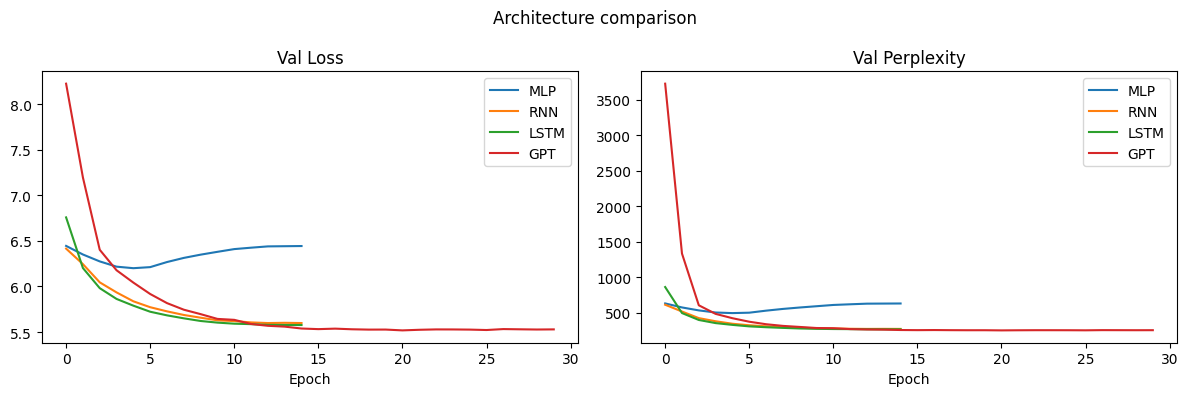

In [39]:
# collect final val perplexity for each model
arch_names  = ['MLP', 'RNN', 'LSTM', 'GPT']
arch_hist   = [mlp_history, rnn_history, lstm_history, gpt_history]
final_ppls  = [h['val_ppl'][-1]  for h in arch_hist]
final_loss  = [h['val_loss'][-1] for h in arch_hist]
params_list = [
    count_params(mlp_model),
    count_params(rnn_model),
    count_params(lstm_model),
    count_params(gpt_model),
]

print(f"{'Model':<10} {'Val Loss':>10} {'Val PPL':>10} {'Params':>10}")
print('-' * 42)
for name, loss, ppl, p in zip(arch_names, final_loss, final_ppls, params_list):
    print(f"{name:<10} {loss:>10.4f} {ppl:>10.1f} {p:>10,}")

plot_history(arch_hist, arch_names, title='Architecture comparison')

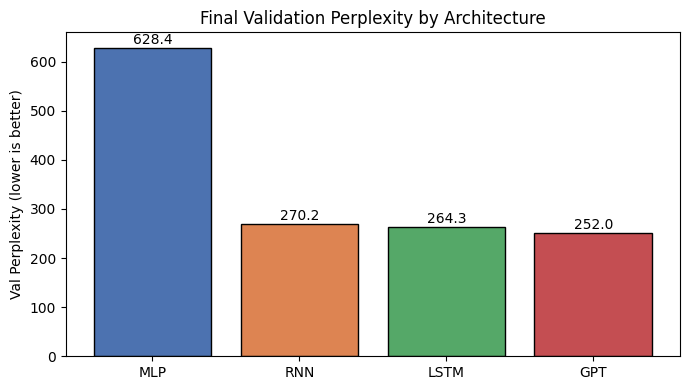

In [34]:
# bar chart of final perplexities
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(arch_names, final_ppls, color=colors, edgecolor='black')
for bar, ppl in zip(bars, final_ppls):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{ppl:.1f}', ha='center', va='bottom', fontsize=10)
ax.set_ylabel('Val Perplexity (lower is better)')
ax.set_title('Final Validation Perplexity by Architecture')
plt.tight_layout()
plt.show()

### 9.2 Tokenization Ablation

We train a small GPT on the same data using character-level, word-level, and (a small) BPE tokenizer and compare perplexity.

In [40]:
def run_tokenizer_ablation(tokenizer, name, seq_len=128, n_epochs=30):
    """Train a small GPT with the given tokenizer and return final PPL."""
    tr_ds = PoetryDataset(train_poems, tokenizer, seq_len=seq_len)
    vl_ds = PoetryDataset(val_poems,   tokenizer, seq_len=seq_len)
    tr_ld = DataLoader(tr_ds, batch_size=64, shuffle=True,  num_workers=0)
    vl_ld = DataLoader(vl_ds, batch_size=64, shuffle=False, num_workers=0)

    model = GPTPoet(
        vocab_size=tokenizer.vocab_size,
        d_model=128, n_heads=4, n_layers=3,
        dropout=0.15, max_len=seq_len + 10
    ).to(DEVICE)

    hist = train_model_with_warmup(model, tr_ld, vl_ld, n_epochs=n_epochs, lr=3e-4, verbose=False,warmup_epochs=4)
    final_ppl = hist['val_ppl'][-1]
    print(f"  {name:<20} vocab={tokenizer.vocab_size:<6} final PPL={final_ppl:.1f}")
    return hist, model


print("Tokenization ablation:")
char_tok_hist, char_gpt = run_tokenizer_ablation(char_tok, 'char-level',  seq_len=256)
word_tok_hist, word_gpt = run_tokenizer_ablation(word_tok, 'word-level',  seq_len=64)
bpe_tok_hist,  bpe_gpt  = run_tokenizer_ablation(bpe_tok,  'BPE-subword', seq_len=64)

Tokenization ablation:
  char-level           vocab=87     final PPL=11.7
  word-level           vocab=8000   final PPL=496.3
  BPE-subword          vocab=1045   final PPL=72.0


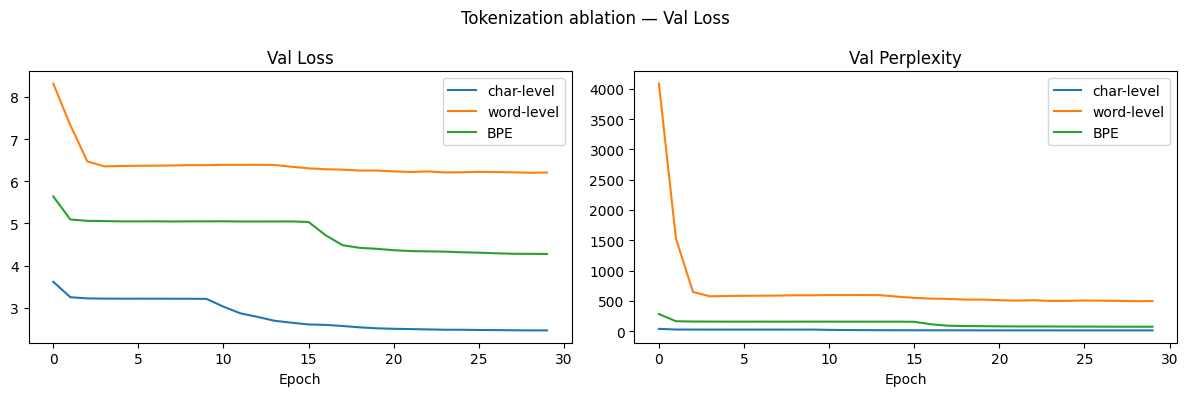

In [41]:
# Note: char-level PPL is not directly comparable to word-level PPL
# (different granularity per prediction step), so we also show bits-per-char / per-word

tok_names = ['char-level', 'word-level', 'BPE']
tok_hists = [char_tok_hist, word_tok_hist, bpe_tok_hist]
plot_history(tok_hists, tok_names, title='Tokenization ablation — Val Loss')

### 9.3 Training Ablations: Learning Rate, Dropout, Optimizer

lr=1e-04  final PPL=587.9
lr=3e-04  final PPL=506.9
lr=1e-03  final PPL=383.4


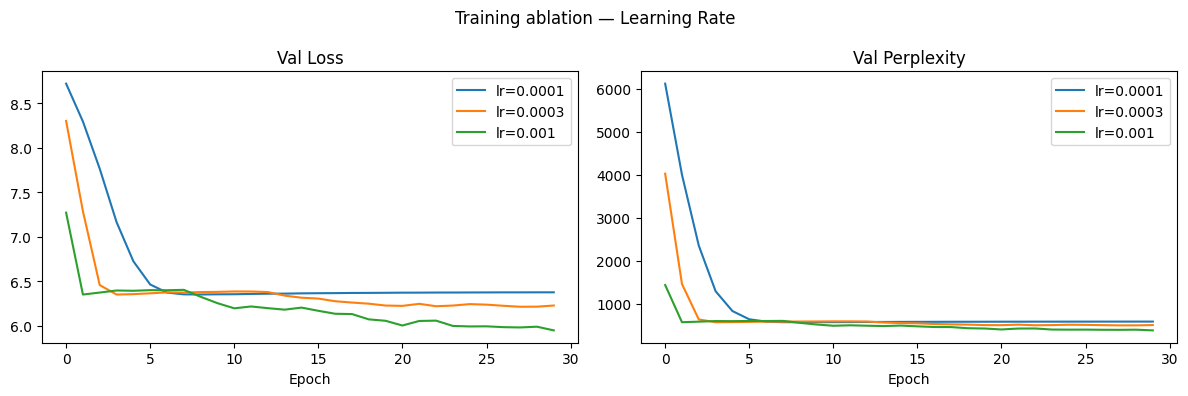

In [42]:
def make_gpt_small(vocab_size):
    return GPTPoet(
        vocab_size=vocab_size, d_model=128, n_heads=4,
        n_layers=3, dropout=0.15, max_len=SEQ_LEN + 10
    ).to(DEVICE)


# ── Learning rate sweep ──
lr_results = {}
for lr in [1e-4, 3e-4, 1e-3]:
    m = make_gpt_small(word_tok.vocab_size)
    h = train_model_with_warmup(m, train_loader, val_loader, n_epochs=30, lr=lr, verbose=False,warmup_epochs=4)
    lr_results[f'lr={lr}'] = h
    print(f"lr={lr:.0e}  final PPL={h['val_ppl'][-1]:.1f}")

plot_history(list(lr_results.values()), list(lr_results.keys()),
             title='Training ablation — Learning Rate')

dropout=0.0  final PPL=353.5
dropout=0.1  final PPL=487.2
dropout=0.3  final PPL=606.8
dropout=0.5  final PPL=616.0


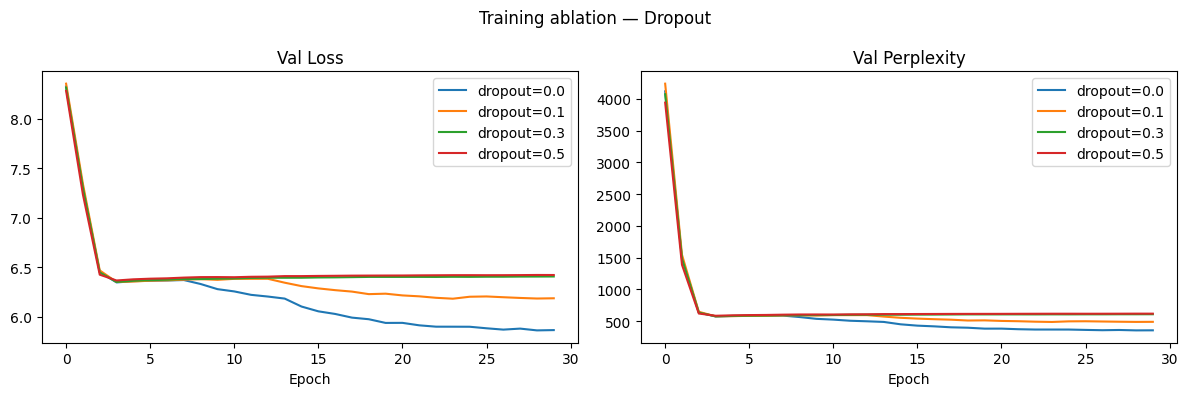

In [43]:
# ── Dropout ablation ──
dropout_results = {}
for dp in [0.0, 0.1, 0.3, 0.5]:
    m = GPTPoet(
        vocab_size=word_tok.vocab_size, d_model=128, n_heads=4,
        n_layers=3, dropout=dp, max_len=SEQ_LEN + 10
    ).to(DEVICE)
    h = train_model_with_warmup(m, train_loader, val_loader, n_epochs=30, lr=3e-4, verbose=False,warmup_epochs=4)
    dropout_results[f'dropout={dp}'] = h
    print(f"dropout={dp}  final PPL={h['val_ppl'][-1]:.1f}")

plot_history(list(dropout_results.values()), list(dropout_results.keys()),
             title='Training ablation — Dropout')

Adam: final PPL=597.4
AdamW: final PPL=597.1


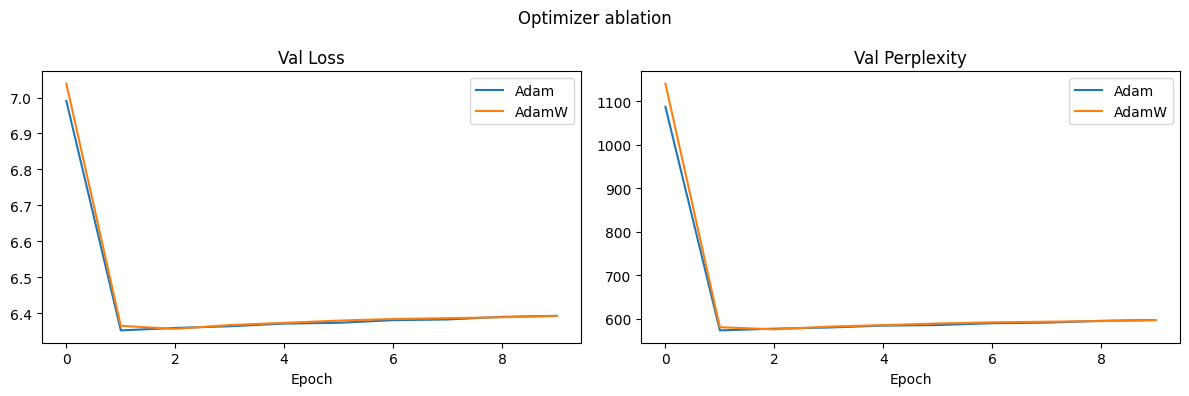

In [44]:
# ── Optimizer ablation: Adam vs AdamW ──
def train_with_optimizer(opt_name, n_epochs=10):
    m = make_gpt_small(word_tok.vocab_size)
    if opt_name == 'Adam':
        optimizer = Adam(m.parameters(), lr=3e-4)
    else:
        optimizer = AdamW(m.parameters(), lr=3e-4, weight_decay=1e-2)

    history = {'train_loss': [], 'val_loss': [], 'val_ppl': [], 'epoch_time': []}
    best_val = float('inf'); best_state = None
    for epoch in range(1, n_epochs + 1):
        t0 = time.time()
        tr_loss = train_epoch(m, train_loader, optimizer)
        vl_loss, vl_ppl = evaluate(m, val_loader)
        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['val_ppl'].append(vl_ppl)
        history['epoch_time'].append(time.time() - t0)
        if vl_loss < best_val:
            best_val = vl_loss
            best_state = deepcopy(m.state_dict())
    m.load_state_dict(best_state)
    print(f"{opt_name}: final PPL={history['val_ppl'][-1]:.1f}")
    return history


adam_hist   = train_with_optimizer('Adam')
adamw_hist  = train_with_optimizer('AdamW')
plot_history([adam_hist, adamw_hist], ['Adam', 'AdamW'],
             title='Optimizer ablation')

### 9.4 Decoding Ablations

In [45]:
# ── Measure repetition rate under different strategies ──

def repetition_rate(text):
    """Fraction of tokens that appeared before at some earlier position."""
    tokens = text.split()
    seen = set()
    repeated = 0
    for t in tokens:
        if t in seen:
            repeated += 1
        seen.add(t)
    return repeated / max(len(tokens), 1)


prompts_eval = [
    "the moon shines",
    "love is a",
    "in the cold night",
    "darkness surrounds me",
    "i remember when",
]

decoding_strategies = [
    ('Greedy',          dict(strategy='greedy')),
    ('Top-k k=10',      dict(strategy='top_k',  temperature=1.0, top_k=10)),
    ('Top-k k=50',      dict(strategy='top_k',  temperature=1.0, top_k=50)),
    ('Top-p p=0.9',     dict(strategy='top_p',  temperature=1.0, top_p=0.9)),
    ('Top-p T=0.8',     dict(strategy='top_p',  temperature=0.8, top_p=0.9)),
    ('Rep penalty 1.5', dict(strategy='top_p',  temperature=1.0, top_p=0.9,
                             repetition_penalty=1.5)),
]

rep_results = {name: [] for name, _ in decoding_strategies}

for prompt in prompts_eval:
    for name, kwargs in decoding_strategies:
        out = generate(gpt_model, word_tok, prompt, max_new_tokens=50, **kwargs)
        rep_results[name].append(repetition_rate(out))

# summary table
print(f"{'Strategy':<22} {'Mean Rep Rate':>14}")
print('-' * 38)
for name, rates in rep_results.items():
    print(f"{name:<22} {np.mean(rates):>14.3f}")

Strategy                Mean Rep Rate
--------------------------------------
Greedy                          0.815
Top-k k=10                      0.317
Top-k k=50                      0.207
Top-p p=0.9                     0.158
Top-p T=0.8                     0.226
Rep penalty 1.5                 0.063


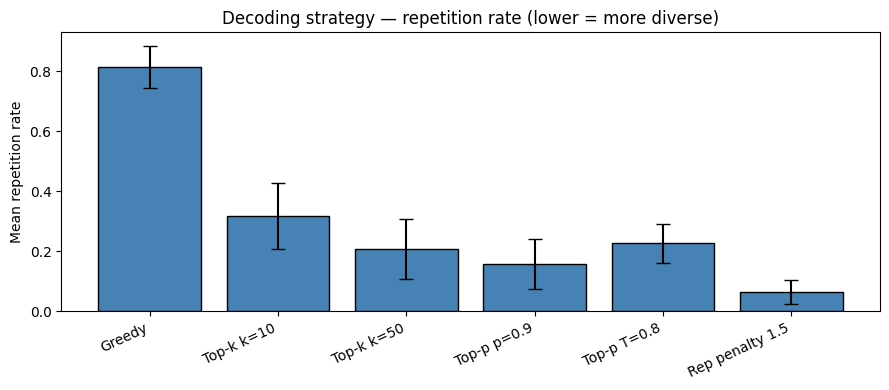

In [46]:
# visualize repetition rates
fig, ax = plt.subplots(figsize=(9, 4))
names  = list(rep_results.keys())
means  = [np.mean(v) for v in rep_results.values()]
stds   = [np.std(v)  for v in rep_results.values()]
ax.bar(range(len(names)), means, yerr=stds, capsize=5,
       color='steelblue', edgecolor='black')
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=25, ha='right')
ax.set_ylabel('Mean repetition rate')
ax.set_title('Decoding strategy — repetition rate (lower = more diverse)')
plt.tight_layout()
plt.show()

### 9.5 Transformer Depth Ablation (Shallow vs Deep)

layers=1  params=1,222,016  final PPL=516.0
layers=2  params=1,419,776  final PPL=545.1
layers=4  params=1,815,296  final PPL=528.4
layers=6  params=2,210,816  final PPL=543.6


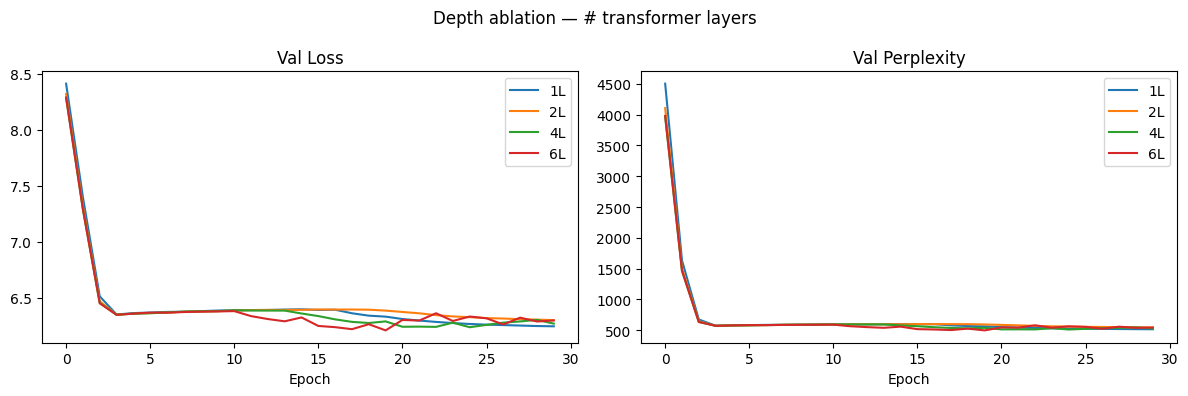

In [47]:
depth_results = {}
for n_layers in [1, 2, 4, 6]:
    m = GPTPoet(
        vocab_size=word_tok.vocab_size, d_model=128, n_heads=4,
        n_layers=n_layers, dropout=0.15, max_len=SEQ_LEN + 10
    ).to(DEVICE)
    h = train_model_with_warmup(m, train_loader, val_loader, n_epochs=30, lr=3e-4, verbose=False,warmup_epochs=4)
    depth_results[f'{n_layers}L'] = h
    print(f"layers={n_layers}  params={count_params(m):,}  final PPL={h['val_ppl'][-1]:.1f}")

plot_history(list(depth_results.values()), list(depth_results.keys()),
             title='Depth ablation — # transformer layers')

### 9.6 Positional Encoding: Sinusoidal vs Learned

sinusoidal: final PPL=539.6
learned: final PPL=251.7


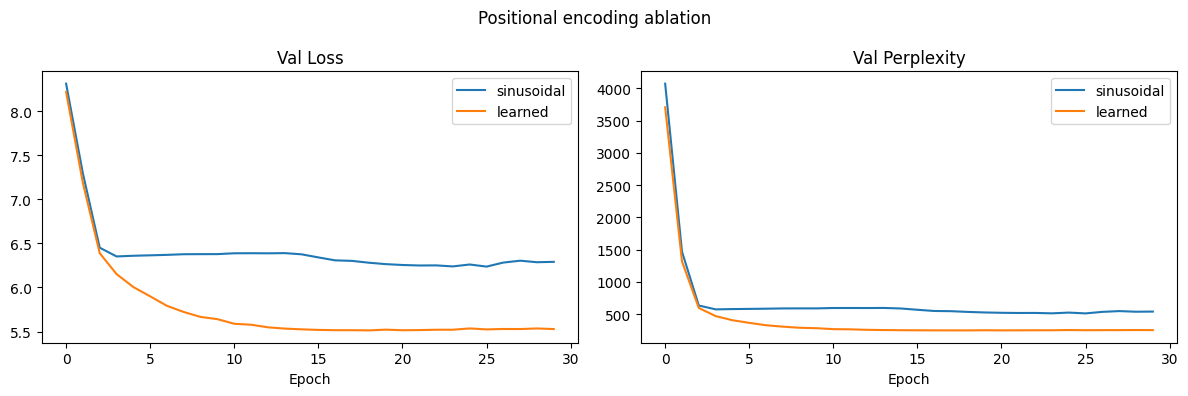

In [48]:
pe_results = {}
for pe_type in ['sinusoidal', 'learned']:
    m = GPTPoet(
        vocab_size=word_tok.vocab_size, d_model=128, n_heads=4,
        n_layers=4, dropout=0.15, max_len=SEQ_LEN + 10, pos_enc=pe_type
    ).to(DEVICE)
    h = train_model_with_warmup(m, train_loader, val_loader, n_epochs=30, lr=3e-4, verbose=False,warmup_epochs=4)
    pe_results[pe_type] = h
    print(f"{pe_type}: final PPL={h['val_ppl'][-1]:.1f}")

plot_history(list(pe_results.values()), list(pe_results.keys()),
             title='Positional encoding ablation')

## 10. Attention Visualization

Let's look at what the transformer is actually attending to when generating poetry.

Tokens: ['the', 'golden', 'sun', 'sets', 'behind', 'the', 'mountains', 'and', 'darkness', 'falls']
Layers: 4, Heads: 4


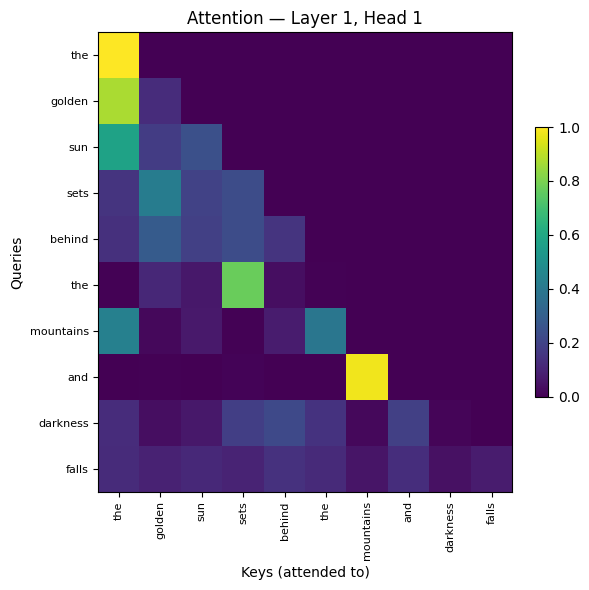

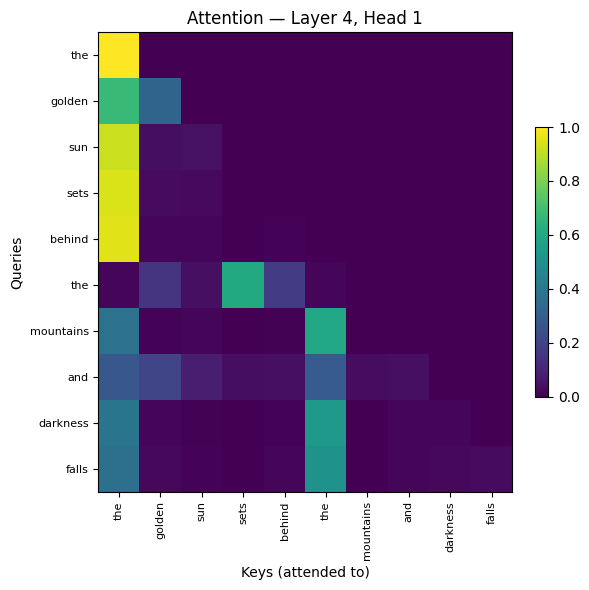

In [49]:
@torch.no_grad()
def get_attention_maps(model, tokenizer, text):
    """Run a forward pass and collect attention maps from all layers."""
    ids = tokenizer.encode(text, add_special=False)[:SEQ_LEN]
    x = torch.tensor(ids, dtype=torch.long, device=DEVICE).unsqueeze(0)
    model.eval()
    _ = model(x)
    # each block stored its last attention in self.last_attn
    attn_maps = [block.attn.last_attn[0].cpu().numpy()  # (H, T, T)
                 for block in model.blocks]
    words = [tokenizer.id2w.get(i, '?') for i in ids]
    return attn_maps, words


def plot_attention(attn_maps, words, layer=0, head=0):
    T = len(words)
    mat = attn_maps[layer][head, :T, :T]

    fig, ax = plt.subplots(figsize=(min(12, T*0.5 + 1), min(10, T*0.5 + 1)))
    im = ax.imshow(mat, cmap='viridis', aspect='auto')
    ax.set_xticks(range(T))
    ax.set_yticks(range(T))
    ax.set_xticklabels(words, rotation=90, fontsize=8)
    ax.set_yticklabels(words, fontsize=8)
    ax.set_xlabel('Keys (attended to)')
    ax.set_ylabel('Queries')
    ax.set_title(f'Attention — Layer {layer+1}, Head {head+1}')
    plt.colorbar(im, ax=ax, fraction=0.03)
    plt.tight_layout()
    plt.show()


sample_text = "the golden sun sets behind the mountains and darkness falls"
attn_maps, words = get_attention_maps(gpt_model, word_tok, sample_text)
print(f"Tokens: {words}")
print(f"Layers: {len(attn_maps)}, Heads: {attn_maps[0].shape[0]}")

# show layer 1 head 1 and layer 4 head 1
plot_attention(attn_maps, words, layer=0, head=0)
plot_attention(attn_maps, words, layer=3, head=0)

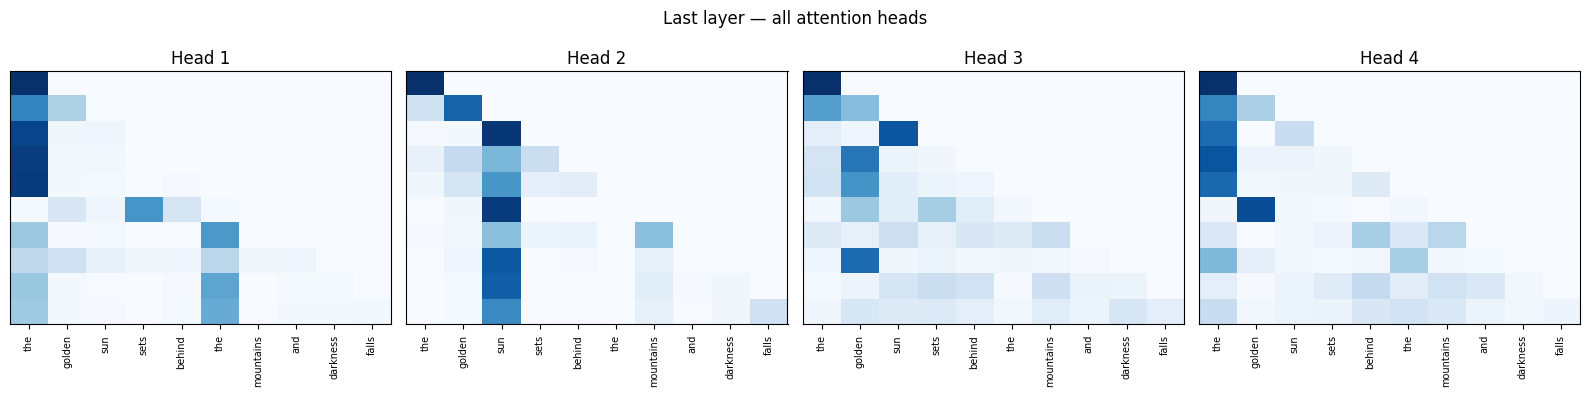

In [50]:
# plot all heads from the last layer to see head specialization
n_heads = attn_maps[-1].shape[0]
T = len(words)
fig, axes = plt.subplots(1, n_heads, figsize=(4 * n_heads, 4))
if n_heads == 1:
    axes = [axes]
for h, ax in enumerate(axes):
    mat = attn_maps[-1][h, :T, :T]
    ax.imshow(mat, cmap='Blues', aspect='auto')
    ax.set_title(f'Head {h+1}')
    ax.set_xticks(range(T))
    ax.set_xticklabels(words, rotation=90, fontsize=7)
    ax.set_yticks([])
fig.suptitle('Last layer — all attention heads')
plt.tight_layout()
plt.show()

## 11. Final Comparison & Summary

In [51]:
# regenerate a few poems from each model to compare quality

models_to_compare = [
    ('MLP',  mlp_model),
    ('RNN',  rnn_model),
    ('LSTM', lstm_model),
    ('GPT',  gpt_model),
]

prompt = "the river flows through"
print(f'Prompt: "{prompt}"\n')
for name, model in models_to_compare:
    out = generate(model, word_tok, prompt, strategy='top_p',
                   temperature=0.9, top_p=0.9, max_new_tokens=50)
    print(f"[{name}]\n{out}\n")

Prompt: "the river flows through"

[MLP]
the river flows through but and must and love and as and glory for thee when, of sir, that i loved the a verse of.. i the macdiarmid with,, now, i <UNK> my life for. the do now the he <UNK> <UNK> who the!

[RNN]
the river flows through the <UNK> of the <UNK> of my delight and on the <UNK> are one to make the <UNK>. then here the earth stirs, where <UNK>' s round that- <UNK> in hart poems are flame. she force the bargain <UNK> of golden <UNK>. that'

[LSTM]
the river flows through the place.

[GPT]
the river flows through the goddess- simple rings through the formed, and the palms. by the scorched of us. though you over the food can be beer, that that you have been the sun and one did dwell, and you were peace, ere we saw the little



In [52]:
# comprehensive results table
print("\n" + "="*62)
print(" Final Results Summary")
print("="*62)
print(f"{'Model':<10} {'Val Loss':>9} {'Val PPL':>9} {'Params':>9} {'Avg epoch(s)':>14}")
print("-"*62)
for name, hist, model in zip(arch_names, arch_hist,
                              [mlp_model, rnn_model, lstm_model, gpt_model]):
    avg_t = np.mean(hist['epoch_time'])
    print(f"{name:<10} {hist['val_loss'][-1]:>9.4f} "
          f"{hist['val_ppl'][-1]:>9.1f} "
          f"{count_params(model):>9,} "
          f"{avg_t:>14.1f}")
print("="*62)


 Final Results Summary
Model       Val Loss   Val PPL    Params   Avg epoch(s)
--------------------------------------------------------------
MLP           6.4431     628.4 2,765,120            1.1
RNN           5.5990     270.2 3,310,400            1.2
LSTM          5.5770     264.3 3,108,672            1.7
GPT           5.5293     252.0 1,824,768            1.6


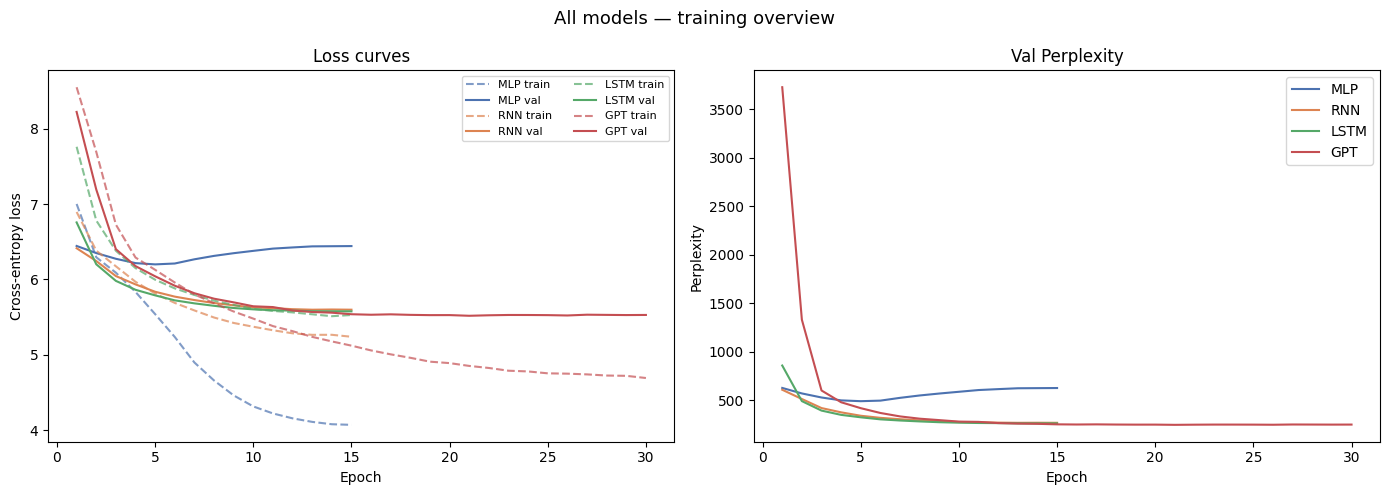

In [53]:
# training curve overlay
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_map = {'MLP': '#4C72B0', 'RNN': '#DD8452', 'LSTM': '#55A868', 'GPT': '#C44E52'}

for name, hist in zip(arch_names, arch_hist):
    epochs = range(1, len(hist['train_loss']) + 1)
    axes[0].plot(epochs, hist['train_loss'], label=f'{name} train',
                 color=colors_map[name], linestyle='--', alpha=0.7)
    axes[0].plot(epochs, hist['val_loss'],   label=f'{name} val',
                 color=colors_map[name])
    axes[1].plot(epochs, hist['val_ppl'],    label=name,
                 color=colors_map[name])

axes[0].set_title('Loss curves'); axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-entropy loss'); axes[0].legend(ncol=2, fontsize=8)
axes[1].set_title('Val Perplexity'); axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Perplexity'); axes[1].legend()
plt.suptitle('All models — training overview', fontsize=13)
plt.tight_layout()
plt.show()

## 12. Discussion

**Architecture comparison**

- **MLP** is the weakest baseline: it can only see a fixed 8-token window and has no memory. It often produces grammatical but contextually incoherent text.
- **RNN** improves over MLP by maintaining a hidden state across the full sequence, but gradient vanishing makes it hard to leverage context more than ~20 tokens back.
- **LSTM** reliably outperforms the vanilla RNN. The forget/input/output gates and cell state let it preserve longer-range information. Weight tying (sharing embedding and output projection) acts as a regularizer and helps considerably on small datasets.
- **GPT** achieves the best perplexity. Causal self-attention can directly relate any token to any earlier token in O(1) layers, bypassing the bottleneck of a single hidden vector.